# Pose Determiner 4

This notebook aims to test the hypothesis that range images as a means of object representation are sufficient to propose candidate views for NBV. The Range images used in the notebook will tbe ground truth images from the virtual scene(Unity).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects

import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
import cv2

from skimage.filters import sobel, scharr
from skimage.feature import blob_dog,blob_doh
from skimage.exposure import adjust_log

from rembg import remove, new_session

import open3d as o3d

from sklearn.cluster import MeanShift
from scipy.spatial.transform import Rotation as R

# Import Pyvista and set backend-trame
import pyvista as pv
pv.set_jupyter_backend('trame')

%matplotlib notebook

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
    
def add_patches_to_plot(ax, blob_list, index=False):
    for index, blob in enumerate(blob_list):
        y, x, r = blob
        c = plt.Circle((x, y), r, color='red', linewidth=2, fill=False)
        ax.add_patch(c)
        txt = ax.text(x, y, str(index), color='white', fontsize=12, 
                     ha='center', va='center')
        if( index ):
            txt.set_path_effects([
                PathEffects.withStroke(linewidth=3, foreground='black')
            ])
        
normalize_depths = lambda arr: (dep_img - dep_img.min()) / (dep_img.max() - dep_img.min())

def create_mask(image, post_process=True):
    '''
        Create a Mask out of an image
    '''
    model_name = "sam" # sam, u2net, silueta, isnet-general-use
    session = new_session(model_name)
    mask = remove(image, only_mask=True, post_process_mask=post_process)
    norm_mask = (mask - mask.min()) / (mask.max() - mask.min())
    return mask

def filter_blobs(blobs, mask):
    
    filtered_blobs = [blob for blob in blobs if mask[ int(blob[0]), int(blob[1]) ] > 0]
    
    return filtered_blobs

# Preliminary Steps

Loading the the coloured and depth image into the notebook and creating their masks.

C:\Users\Kibzyzii\AppData\Local\Temp\ipykernel_15184\3508137818.py:32: RuntimeWarning: invalid value encountered in divide
  Nx = Z_x / normal_length
C:\Users\Kibzyzii\AppData\Local\Temp\ipykernel_15184\3508137818.py:33: RuntimeWarning: invalid value encountered in divide
  Ny = Z_y / normal_length
C:\Users\Kibzyzii\AppData\Local\Temp\ipykernel_15184\3508137818.py:34: RuntimeWarning: divide by zero encountered in divide
  Nz = 1.0 / normal_length


<IPython.core.display.Javascript object>


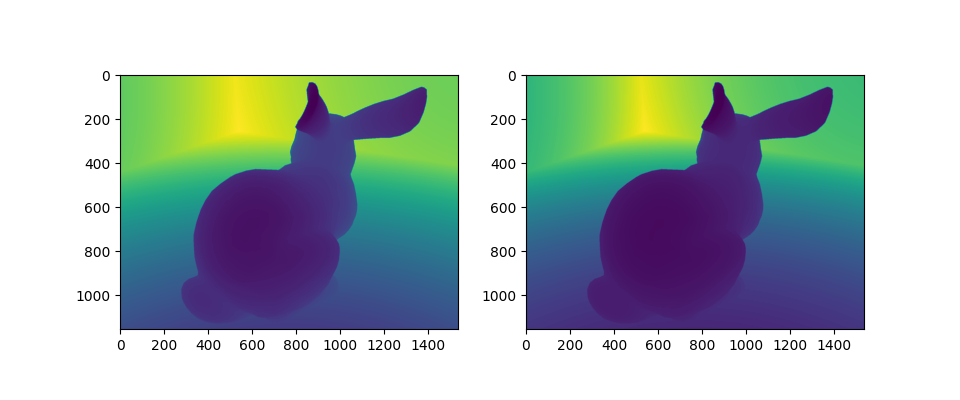

In [3]:
src_name = "./DepthAnalysis/StanfordBunny/4"
col_img = cv2.cvtColor(cv2.imread(src_name+".jpg"), cv2.COLOR_BGR2RGB)
dep_img = cv2.imread(src_name+".exr", cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH).astype(np.float32) * 10
mask = create_mask(dep_img)

img_width = col_img.shape[1]
img_height = col_img.shape[0]

focal_l = 6.0
fx, fy = (focal_l *  img_width/6.287, focal_l *  img_width/6.287)
cx, cy = ( img_width/2, img_height/2 )
intrinsics = o3d.camera.PinholeCameraIntrinsic(img_width, img_height, fx, fy, cx, cy)

# col_img = mask_out( mask, col_img )
# dep_img = mask_out( mask, dep_img )

# Calculate Occupancy
area = mask[mask > 0].size
occupancy = area/mask.size

# ratio of circle representing the area of occupied pixels
occp_ratio = int(np.sqrt(area / np.pi)) 

def compute_gradient_centralDiff(depth_map):
    # Compute the gradients
    Z_y, Z_x = np.gradient(depth_map) 

    # Normalize the gradients
    normal_length = np.sqrt(Z_x**2 + Z_y**2)

    # Compute the normals
    Nx = Z_x / normal_length
    Ny = Z_y / normal_length
    Nz = 1.0 / normal_length

    # Stack the channels
    gradient = np.dstack((Nx, Ny, Nz)) # dstack???

    return gradient
grd_img = compute_gradient_centralDiff(dep_img)
fig, axs = plt.subplots(1,2, figsize=(9.6,4))

axs[0].imshow(adjust_log(dep_img))
axs[1].imshow(dep_img)

# Feature Detection

- We leverage depth map information of the foreground object for surface topology information.
- Variations in intensity across the depth map reveal the object's three-dimensional shape and contours
    - Gradual changes represent smoot sloping surfaces
    - Abrupt changes may indicate sharp edges or sharp features
    - Sharp Changes in intensities often represent object boundaries
- The geometric complexity of shaped features can lead to reconstruction inaccuracies: likelihood of reconstruction errors especially if high-resolution datasets are not utilised for reconstruction. Complex geometries also results in challenges in feature matching which include geometric distortions and self-occlusions.
- We refer to such ares with sharp features as geometries of interest and those are the features of intereset.
- We perform convolutions of a depth of image across multiple gaussian scales to obtain the features of interest

Talking points:
- What features are we interested in and why? Also what is the size of the features to be considered? What are some heuristics that can be used to pick on a given blob scale.
    We compute blobs against the depth image to detect irregularity on the surface and deformations.
- What feature detection algorithm are we going to use and why not use a complete feature extraction. Feature detectors are usually a precursor to feature extractors. They are fast and efficient. 


### Observations:

- Using a normalized Image will require using lower thresholds. The raw depth image is more sensitive to the DoG convolution.
- This means that more features are going to be detected using the raw depth

In [4]:
# Initialise Sigma Values
min_sigma = int(occp_ratio*.04)
max_sigma = int(occp_ratio*.2)
def compute_blobs(img):    
    # Compute blobs from the Depth Map
    return blob_dog(img, min_sigma=min_sigma, max_sigma=max_sigma, threshold=.001)
#dep_blobs = compute_blobs( dep_img)

# Filtering out the Blobs
Since this is a multiview problem, 

<IPython.core.display.Javascript object>


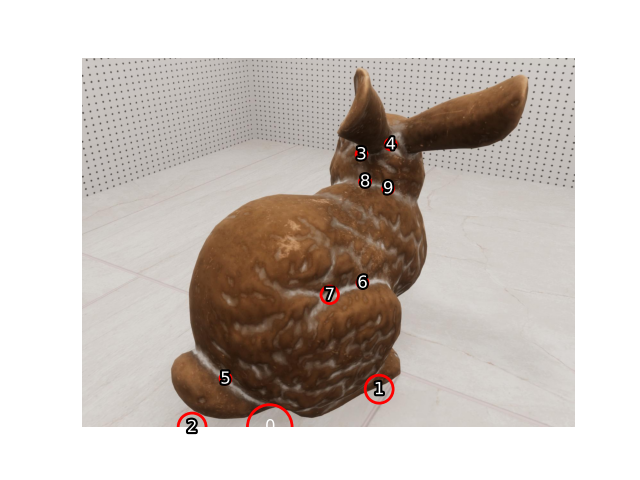

(-0.5, 1535.5, 1151.5, -0.5)

In [5]:
dep_blobs = compute_blobs( dep_img)
fitlered_blobs = np.array(filter_blobs(dep_blobs, mask))
fig, ax = plt.subplots()
add_patches_to_plot(ax, fitlered_blobs)
ax.imshow(col_img)
ax.axis("off")

# Cluster Blobs

<IPython.core.display.Javascript object>


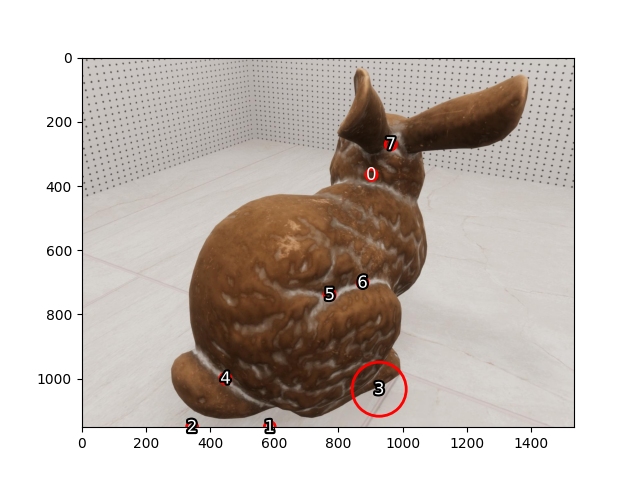

In [6]:
selected_bandwidth = ((occp_ratio * .2))

# Applying Mean Shift Clustering
meanshift = MeanShift(bandwidth=selected_bandwidth)
meanshift.fit(fitlered_blobs[:,:2])
labels = meanshift.labels_
cluster_centers = meanshift.cluster_centers_
n_clusters = len(cluster_centers)

blobs_dict = dict()
for label, blob in zip(labels, fitlered_blobs):
    if label in blobs_dict:
        blobs_dict[label].append(blob)
    else:
        blobs_dict[label] = [blob]

blobs_radii = {}
# Loop over Clusters
for key, blobs in blobs_dict.items():
    _blobs = np.asarray(blobs)    
    if( len(blobs) == 1 ):
        radius = blob[2]
    else:
        x_len = max(_blobs[:,0]) - min(_blobs[:,0])
        y_len = max(_blobs[:,1]) - min(_blobs[:,1])
        radius =  np.sqrt( y_len**2 + x_len**2)/2 + np.mean(_blobs[:,2:])
    blobs_radii[key] = radius 
    
# Form a Blob Structure (x,y radius)
blobs = np.column_stack([cluster_centers, np.array( list(blobs_radii.values()), dtype=float )])
plt.figure()
plt.imshow(col_img)
add_patches_to_plot( plt.gca(), blobs )

## Calculation of Poses

Now we have a list of RoIs. We can now loop over them while calculating their poses.

In [7]:
def isolate_image(image, roi):
    # Extracting the center (y, x) and radius
    y, x, radius = roi
    
    # Calculating the square bounds
    top_y = max(int(y - radius), 0)
    left_x = max(int(x - radius), 0)
    bottom_y = min(int(y + radius), image.shape[0])
    right_x = min(int(x + radius), image.shape[1])

    # Create 
    masked = np.zeros_like(image)    
    cropped_image = image[top_y:bottom_y, left_x:right_x]
    masked[top_y:bottom_y, left_x:right_x] = cropped_image

    return masked

def create_point_cloud(extractions, focal_l = 6):
    img_rgb, img_dep = extractions
    
    # Scaling factor for the depth image
    _scale = 1000
    
    color_raw_m = o3d.geometry.Image(img_rgb)
    depth_raw_m =  o3d.geometry.Image(img_dep*_scale) 
    
    # Create RGBD 
    rgbd_image_m = o3d.geometry.RGBDImage.create_from_color_and_depth(
        color_raw_m, 
        depth_raw_m
    )
    
#     intrinsics = o3d.camera.PinholeCameraIntrinsic(o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault)
    # Create Point Cloud
    pcd = o3d.geometry.PointCloud.create_from_rgbd_image( rgbd_image_m, intrinsics )

    # Estimate Normals
    pcd.estimate_normals( search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=.1, max_nn=30))
    pcd.orient_normals_towards_camera_location()

    # Create Numpy Arrays for the points and corresponding normals.
    pcd_p = np.asarray(pcd.points)
    pcd_n = np.asarray(pcd.normals)
    
    return pcd, pcd_p, pcd_n


def retrieve_normal(points, normals):
    # Calculate the centroid
    centroid = np.mean(points, axis=0)
    normal = np.mean(normals, axis=0)

    # Find the index of the point closest to the centroid
    distances = np.linalg.norm(points - centroid, axis=1)
    closest_point_index = np.argmin(distances)

    # Get the normal at the closest point
    closest_normal = normals[closest_point_index]
    
    return centroid, (closest_normal+normal)/2

def add_normal_to_plotter(plotter, point, normal, col="red"):
    arrow = pv.Arrow(start=point, direction=normal, scale=.2)  # Adjust scale as needed
    plotter.add_mesh(arrow, color=col)

def normalise_vector(vec):
    norm = np.linalg.norm(vec)
    if norm == 0: 
        normalized_v = vec
    else:
        normalized_v = vec / norm
    
    return normalized_v

    # Convert the input lists to numpy arrays
    v1 = np.array(vector1)
    v2 = np.array(vector2)

    # Calculate the dot product of the two vectors
    dot_product = np.dot(v1, v2)

    # Calculate the magnitudes of the vectors
    magnitude_v1 = np.linalg.norm(v1)
    magnitude_v2 = np.linalg.norm(v2)

    # Calculate the cosine of the angle between the vectors
    cosine_theta = dot_product / (magnitude_v1 * magnitude_v2)

    # Use arccosine to get the angle in radians
    angle_radians = np.arccos(cosine_theta)

    # Convert the angle to degrees
    angle_degrees = np.degrees(angle_radians)

    return angle_degrees

def angle_difference(v1, v2):
    '''
        Returns: angle_degrees and angle_radians
    '''
    dot_product = np.dot(v1, v2)

    magnitude_v1 = np.linalg.norm(v1)
    magnitude_v2 = np.linalg.norm(v2)

    # Calculate the cosine of the angle between the vectors
    cosine_theta = dot_product / (magnitude_v1 * magnitude_v2)

    # Use arccosine to get the angle in radians
    angle_radians = np.arccos(cosine_theta)

    # Convert the angle to degrees
    angle_degrees = np.degrees(angle_radians)

    return angle_degrees, angle_radians

# Generating Poses

Order of generating poses:
- Define Boundaries for new camera poses: Max and Minimum WD, Ground Obstacle Avoidance
    - Min WD is defined as the mean_radius + 2std_dev 
- Iterate over Blobs
- Isolate blob
- Compute Normal vector for the Blob
- Compute Primary Pose
- Compute constraints for secondary pose

## Estimation of Baseline-Depth Ratios:
- Of Interest is baseline between the primary and the secondary poses.
- Both poses intend to increase coverage of the the Geometry of Interest
- Ideal Baseline-Depth Ratios are required, to **maximize triangulation** and **feature-matching**
- The depths of the primary poses are a function of the blob sizes. 
- The secondary poses are a function of the primary pose, the centroid of the object and an angle $\theta$

In [8]:
# Hold all the Poses
local_poses = list()

roi_pos = list()

def generate_poses(plotter, blobs, image_col_m, image_dep_m, ):
    for blob in blobs:
        # Get Blob Centroid and Normal
        roi_col = isolate_image( image_col_m, blob )
        roi_dep = isolate_image( image_dep_m, blob )
        pcd, points, normals = create_point_cloud( [ roi_col, roi_dep ] )
        centroid, normal = retrieve_normal(points, normals)
        
        roi_pos.append(centroid)
        
        # Create and add a sphere to represent a single point
        sphere = pv.Sphere(radius=.02, center=centroid)
        plotter.add_mesh(sphere, color='blue')
        
        # Calculate Primary Pose Position and Orientation
        blob_size_s = int(blob[2])/Rad
        wd = np.clip( blob_size_s * WD, min_wd, WD )
        priPose_loc = (normal * wd) + centroid
        
        # Avoid Floor Collision
        if priPose_loc[1] < y_min:
            print(f"Point: {priPose_loc} is below the floor at {y_min}" )
            priPose_loc[1] = y_min
            print(f"New Position: {priPose_loc}")
        priPose_rot = normalise_vector(centroid - priPose_loc)
        local_poses.append({ "pos" : priPose_loc, "rot" : priPose_rot })
        add_normal_to_plotter(plotter,priPose_loc, priPose_rot, "blue")

        # Get Secondary Pose
        v1 = priPose_loc - centroid
        v2 = viewpoint_centroid - centroid
        _, internal_angle = angle_difference(v1, v2)
        delta_angle = np.pi - internal_angle
        
        # Calculate Secondary Pose
        normal = np.cross(v1, v2)
        rot_axis = normal / np.linalg.norm(normal)
        theta = -np.pi/12
        
        quat = R.from_rotvec(theta * rot_axis) # Create a quaternion for the rotation
        secPose_loc = quat.apply(v1) + centroid
        
        if secPose_loc[1] < y_min:
            print(f"Point: {secPose_loc} is below the floor at {y_min}" )
            secPose_loc[1] = y_min
            
            v3 = secPose_loc - centroid
            v4 = priPose_loc - centroid
            _deg, delta_angle2 = angle_difference(v3, v4)
            
            print(f"New Angle Delta: {_deg}")
            
            rot_axis2 = np.cross(v3, v4)
            rot_axis2 = rot_axis2/ np.linalg.norm(rot_axis2)
            quat2 = R.from_rotvec( (theta - delta_angle2)/2  * rot_axis2) # Create a quaternion for the rotation
            secPose_loc = quat2.apply(v3) + centroid
            secPose_loc[1] = y_min
            
        secPose_rot = normalise_vector( centroid - secPose_loc )
        local_poses.append({ "pos" : secPose_loc, "rot" : secPose_rot })
        add_normal_to_plotter(plotter,secPose_loc, secPose_rot, "yellow")
        
        
# Prepare the Point Cloud
viewpoint_pcd,viewpoint_points, viewpoint_normals = create_point_cloud( [ col_img, dep_img ] )
viewpoint_centroid = np.mean(viewpoint_points, axis=0)

# Get Baselines for Blob Radius and Primar Pose Distance
eds = np.sqrt(np.sum((viewpoint_points - viewpoint_centroid)**2, axis=1))
ed_mean = np.mean(eds) 
ed_stdv = np.std(eds)
min_wd = ed_mean + (2 * ed_stdv)

WD = np.min(dep_img[mask > 0])
Rad = int(np.max(blobs[:,2]))
camera_offset = 0.1
y_min = np.ceil( np.min(viewpoint_points[:,1]) * 100)/100 + camera_offset

plotter = pv.Plotter()
vp_cloud = pv.PolyData(viewpoint_points)
plotter.add_points(vp_cloud, point_size=1)#, render_points_as_spheres=True)

generate_poses(plotter, blobs, col_img, dep_img)

# Create and add a sphere to represent a single point
centroid_sphere = pv.Sphere(radius=.05, center=viewpoint_centroid)

plotter.add_mesh(centroid_sphere, color='green')
plotter.view_xz()
plotter.show_grid()
plotter.show_axes()
plotter.show()


Point: [-0.11596241 -0.71033863  0.57740663] is below the floor at -0.47
New Angle Delta: 5.922882220252362
Point: [ 1.0118977  -0.64817116  0.79942853] is below the floor at -0.47
New Angle Delta: 7.126545891914656


Widget(value='<iframe src="http://localhost:60735/index.html?ui=P_0x1d502f4a500_0&reconnect=auto" class="pyvis…

In [9]:
def create_list_c(A, B):
    C = []
    for i in range(len(A)):
        # Get two consecutive 'pos' values from B for each element in A
        pos1 = B[2*i]['pos'] * np.array([1,-1,1])
        pos2 = B[2*i + 1]['pos'] * np.array([1,-1,1])
        
        C.append([A[i]* np.array([1,-1,1]), pos1, pos2])
    return C
create_list_c(roi_pos,local_poses)

[[array([0.16402008, 0.25918768, 1.78787707]),
  array([-0.22873082,  0.38736066,  0.53229574]),
  array([0.05753422, 0.47      , 0.58528539])],
 [array([-0.22270815, -0.69126628,  1.78877488]),
  array([-0.3209209 ,  0.29973416,  0.91462565]),
  array([-0.52494094,  0.07399444,  0.75007575])],
 [array([-0.53296134, -0.7111983 ,  1.84035357]),
  array([-0.82672103,  0.22869913,  0.95344112]),
  array([-1.10583416,  0.03051745,  0.9033423 ])],
 [array([ 0.20073552, -0.57416864,  1.84451982]),
  array([ 0.68443481, -0.67670287,  0.8972521 ]),
  array([ 0.73237379, -0.93509669,  0.99077156])],
 [array([-0.35999756, -0.47570254,  1.64645607]),
  array([-0.24910278, -0.69588014,  0.41718763]),
  array([-0.55548165, -0.80537631,  0.45273168])],
 [array([ 0.00468591, -0.16794006,  1.5149496 ]),
  array([ 0.54075322, -0.08607361,  0.32883404]),
  array([0.22760662, 0.01654949, 0.24325373])],
 [array([ 0.11583733, -0.13532483,  1.59358358]),
  array([ 0.94113528, -0.0476735 ,  0.64663385]),
  a

In [10]:
create_list_c(roi_pos,local_poses)

[[array([0.16402008, 0.25918768, 1.78787707]),
  array([-0.22873082,  0.38736066,  0.53229574]),
  array([0.05753422, 0.47      , 0.58528539])],
 [array([-0.22270815, -0.69126628,  1.78877488]),
  array([-0.3209209 ,  0.29973416,  0.91462565]),
  array([-0.52494094,  0.07399444,  0.75007575])],
 [array([-0.53296134, -0.7111983 ,  1.84035357]),
  array([-0.82672103,  0.22869913,  0.95344112]),
  array([-1.10583416,  0.03051745,  0.9033423 ])],
 [array([ 0.20073552, -0.57416864,  1.84451982]),
  array([ 0.68443481, -0.67670287,  0.8972521 ]),
  array([ 0.73237379, -0.93509669,  0.99077156])],
 [array([-0.35999756, -0.47570254,  1.64645607]),
  array([-0.24910278, -0.69588014,  0.41718763]),
  array([-0.55548165, -0.80537631,  0.45273168])],
 [array([ 0.00468591, -0.16794006,  1.5149496 ]),
  array([ 0.54075322, -0.08607361,  0.32883404]),
  array([0.22760662, 0.01654949, 0.24325373])],
 [array([ 0.11583733, -0.13532483,  1.59358358]),
  array([ 0.94113528, -0.0476735 ,  0.64663385]),
  a